In [1]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("../data/transactions.csv")
disputes = pd.read_csv("../data/disputes.csv")

In [2]:
transactions.head()

,transaction_id,merchant_id,transaction_date,amount,channel,customer_segment,merchant_name,merchant_segment,merchant_city,dispute_probability,is_disputed
0,1,376,2025-12-10 05:00:00,1912.65,E-commerce,Mass,Merchant_00376,Retail,Gurugram,0.032,0
1,2,2508,2025-12-12 03:00:00,1072.29,E-commerce,Mass,Merchant_02508,Services,Bengaluru,0.032,0
2,3,2850,2025-08-08 03:00:00,1554.60,E-commerce,Premium,Merchant_02850,Travel,Delhi,0.036,0
3,4,3662,2025-05-27 14:00:00,3840.89,Card Present,Mass,Merchant_03662,Services,Bengaluru,0.022,0
4,5,2861,2025-07-25 21:00:00,1635.37,E-commerce,Mass,Merchant_02861,Travel,Pune,0.036,0


In [3]:
disputes.head()

,transaction_id,merchant_id,merchant_name,merchant_segment,merchant_city,transaction_date,channel,customer_segment,amount,dispute_reason,dispute_amount,response_days,merchant_won,chargeback_amount
0,42,296,Merchant_00296,Services,Bengaluru,2025-01-06 03:00:00,E-commerce,Mass,1575.86,Fraud,1575.86,2,0,1575.86
1,129,437,Merchant_00437,Retail,Bengaluru,2025-07-26 11:00:00,E-commerce,Mass,3646.94,Goods Not Received,3646.94,2,1,0.00
2,187,108,Merchant_00108,Retail,Delhi,2025-08-06 15:00:00,Mobile,Mass,2462.96,Goods/Services Returned,2462.96,3,1,0.00
3,189,1094,Merchant_01094,Retail,Pune,2025-09-20 09:00:00,Mobile,Mass,781.35,Fraud,781.35,5,1,0.00
4,197,2572,Merchant_02572,Restaurant,Gurugram,2025-08-18 20:00:00,Card Present,Small Business,570.82,Billing Error,570.82,3,0,570.82


In [4]:
transactions.shape

(500000, 11)

In [5]:
disputes.shape

(13806, 14)

In [6]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaction_id       500000 non-null  int64  
 1   merchant_id          500000 non-null  int64  
 2   transaction_date     500000 non-null  str    
 3   amount               500000 non-null  float64
 4   channel              500000 non-null  str    
 5   customer_segment     500000 non-null  str    
 6   merchant_name        500000 non-null  str    
 7   merchant_segment     500000 non-null  str    
 8   merchant_city        500000 non-null  str    
 9   dispute_probability  500000 non-null  float64
 10  is_disputed          500000 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 72.2 MB


In [7]:
disputes.info()

<class 'pandas.DataFrame'>
RangeIndex: 13806 entries, 0 to 13805
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     13806 non-null  int64  
 1   merchant_id        13806 non-null  int64  
 2   merchant_name      13806 non-null  str    
 3   merchant_segment   13806 non-null  str    
 4   merchant_city      13806 non-null  str    
 5   transaction_date   13806 non-null  str    
 6   channel            13806 non-null  str    
 7   customer_segment   13806 non-null  str    
 8   amount             13806 non-null  float64
 9   dispute_reason     13806 non-null  str    
 10  dispute_amount     13806 non-null  float64
 11  response_days      13806 non-null  int64  
 12  merchant_won       13806 non-null  int64  
 13  chargeback_amount  13806 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 2.5 MB


In [8]:
transactions["amount"].describe()

count    500000.000000
mean       1775.246345
std        1539.307105
min          35.860000
25%         809.647500
50%        1339.780000
75%        2224.910000
max       36778.590000
Name: amount, dtype: float64

In [9]:
total_transactions = len(transactions)
total_disputes = len(disputes)
dispute_rate = round((total_disputes/total_transactions) * 100, 2)
print("Dispute rate:", dispute_rate)

Dispute rate: 2.76


In [10]:
total_disputed_amount = disputes["dispute_amount"].sum()
total_chargeback_amount = disputes["chargeback_amount"].sum()
print("Total disputed amount:", round(total_disputed_amount, 2))
print("Total chargeback amount:", round(total_chargeback_amount, 2))


Total disputed amount: 24794577.62
Total chargeback amount: 9202533.1


In [11]:
segment_summary = (disputes.groupby("merchant_segment").agg(
    disputes = ("transaction_id", "count"),
    chargeback_amount = ("chargeback_amount", "sum")
).sort_values("chargeback_amount", ascending=False).reset_index())

print(segment_summary)

  merchant_segment  disputes  chargeback_amount
0           Retail      3586         2355373.37
1          Digital      3031         2106604.39
2       Restaurant      2616         1713309.78
3           Travel      2585         1698326.59
4         Services      1988         1328918.97


In [12]:
reason_summary = (
    disputes
    .groupby("dispute_reason")
    .agg(
        disputes=("transaction_id", "count"),
        chargeback_amount=("chargeback_amount", "sum")
    )
    .sort_values("chargeback_amount", ascending=False)
    .reset_index()
)

print(reason_summary)

            dispute_reason  disputes  chargeback_amount
0                    Fraud      3766         2535975.25
1            Billing Error      3038         1986558.19
2       Goods Not Received      2704         1813607.14
3  Goods/Services Returned      2555         1708557.83
4     Duplicate Processing      1743         1157834.69


In [13]:
response_summary = (
    disputes
    .groupby("response_days")
    .agg(
        disputes=("transaction_id", "count"),
        win_rate=("merchant_won", "mean")
    )
    .reset_index()
)

print(response_summary)

    response_days  disputes  win_rate
0               1      1791  0.759352
1               2      2332  0.738851
2               3      2185  0.693364
3               4      1956  0.637014
4               5      1521  0.575279
5               6      1230  0.564228
6               7       874  0.498856
7               8       615  0.484553
8               9       430  0.439535
9              10       281  0.409253
10             11       202  0.287129
11             12       135  0.325926
12             13        84  0.214286
13             14        51  0.117647
14             15        39  0.205128
15             16        29  0.241379
16             17        19  0.368421
17             18        12  0.333333
18             19         7  0.285714
19             20         3  0.000000
20             21         3  0.333333
21             22         1  0.000000
22             23         1  0.000000
23             24         1  0.000000
24             25         3  0.000000
25          

observed an association between response time and merchant win rate and used it as a hypothesis for further investigation

In [14]:
disputes["transaction_date"] = pd.to_datetime(
    disputes["transaction_date"],
    errors="coerce"
)

monthly = (
    disputes
    .groupby(
        disputes["transaction_date"].dt.to_period("M")
    )
    .agg(
        disputes=("transaction_id", "count"),
        chargeback_amount=("chargeback_amount", "sum")
    ).reset_index()
)

print(monthly)

   transaction_date  disputes  chargeback_amount
0           2025-01      1121          720714.04
1           2025-02      1059          727347.29
2           2025-03      1154          755956.37
3           2025-04      1183          771594.30
4           2025-05      1174          739832.41
5           2025-06      1116          797008.27
6           2025-07      1161          842436.30
7           2025-08      1206          758104.17
8           2025-09      1133          717214.75
9           2025-10      1229          790195.56
10          2025-11      1188          844217.38
11          2025-12      1082          737912.26


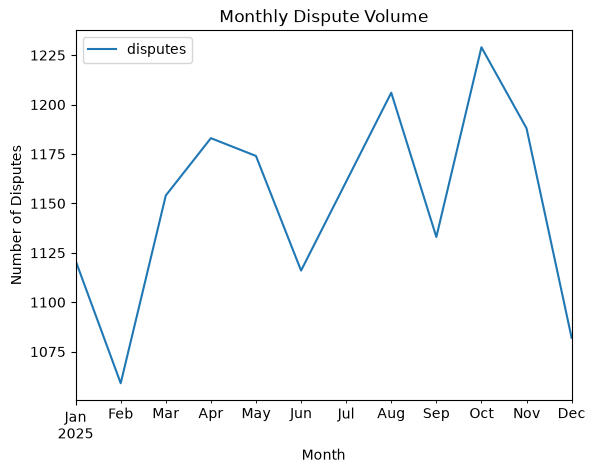

In [15]:
import matplotlib.pyplot as plt

monthly.plot(
    x="transaction_date",
    y="disputes",
    kind="line"
)

plt.title("Monthly Dispute Volume")
plt.xlabel("Month")
plt.ylabel("Number of Disputes")
plt.show()

In [18]:
from google import genai
from dotenv import load_dotenv
load_dotenv()
client = genai.Client()

def generate_ops_briefing():
    prompt = f"""
                You are a junior business analyst preparing a short update for an operations manager.
                Use ONLY the metrics provided below.
                Metrics: -
                - Total disputes: {total_disputes}
                - Dispute rate: {dispute_rate}%
                - Chargeback amount: ${total_chargeback_amount}
                - Top merchant segment: {segment_summary.iloc[0]["merchant_segment"]}
                - Top dispute reason: {reason_summary.iloc[0]["dispute_reason"]}
                - Average response time: {disputes['response_days'].mean().round(1)} days
                   
                Write:
                1. Two sentences summarizing what happened.
                2. Two bullet points describing the main drivers.
                3. Two practical questions the operations team should investigate.
                
                Do not invent any numbers.
                Do not claim causation.    
              """

    
    return client.models.generate_content(model="gemini-3.6-flash", contents=prompt).text
print(generate_ops_briefing())

**Summary**
During the evaluated period, a total of 13,806 disputes were recorded, resulting in a 2.76% dispute rate and a chargeback amount of $9,202,533.1. Operations recorded an average response time of 4.4 days, with Retail identified as the top merchant segment and Fraud as the top dispute reason.

**Main Drivers**
* **Merchant Segment:** Retail is the top merchant segment in the dispute metrics.
* **Dispute Category:** Fraud is the top dispute reason listed.

---

### Answers to Questions

1. **Are disputes increasing?** 
   The provided metrics do not include historical or trend data, so it cannot be determined if disputes are increasing.

2. **Which merchant segment drive the increase?** 
   Because trend data is not provided, an increase cannot be measured; however, Retail is identified as the top merchant segment.

3. **Which dispute reasons dominate?** 
   Fraud is the top dispute reason.

4. **Where are response delays associated with poor outcomes?** 
   The metrics show a